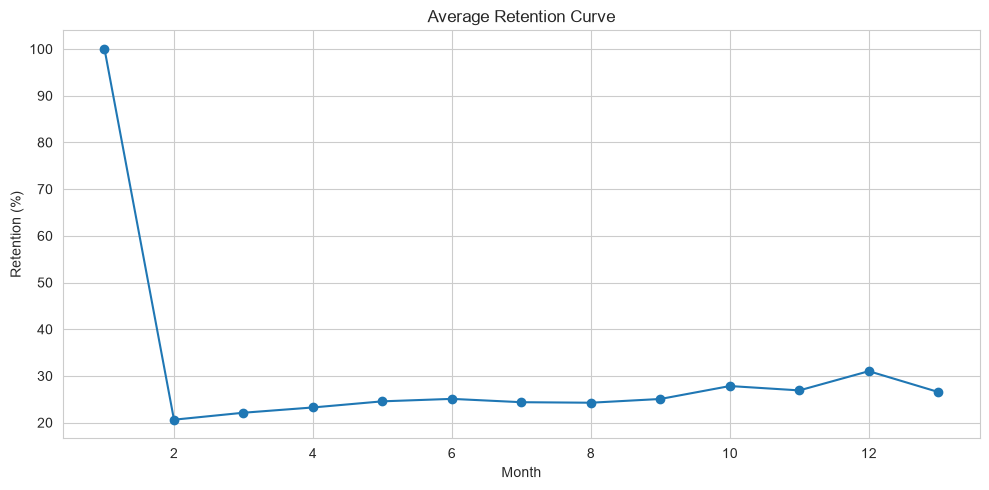

In [38]:
average_retention = retention.mean()

plt.figure(figsize=(10, 5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o"
)

plt.title("Average Retention Curve")

plt.xlabel("Month")

plt.ylabel("Retention (%)")

plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/retention_curve.png")

plt.show()

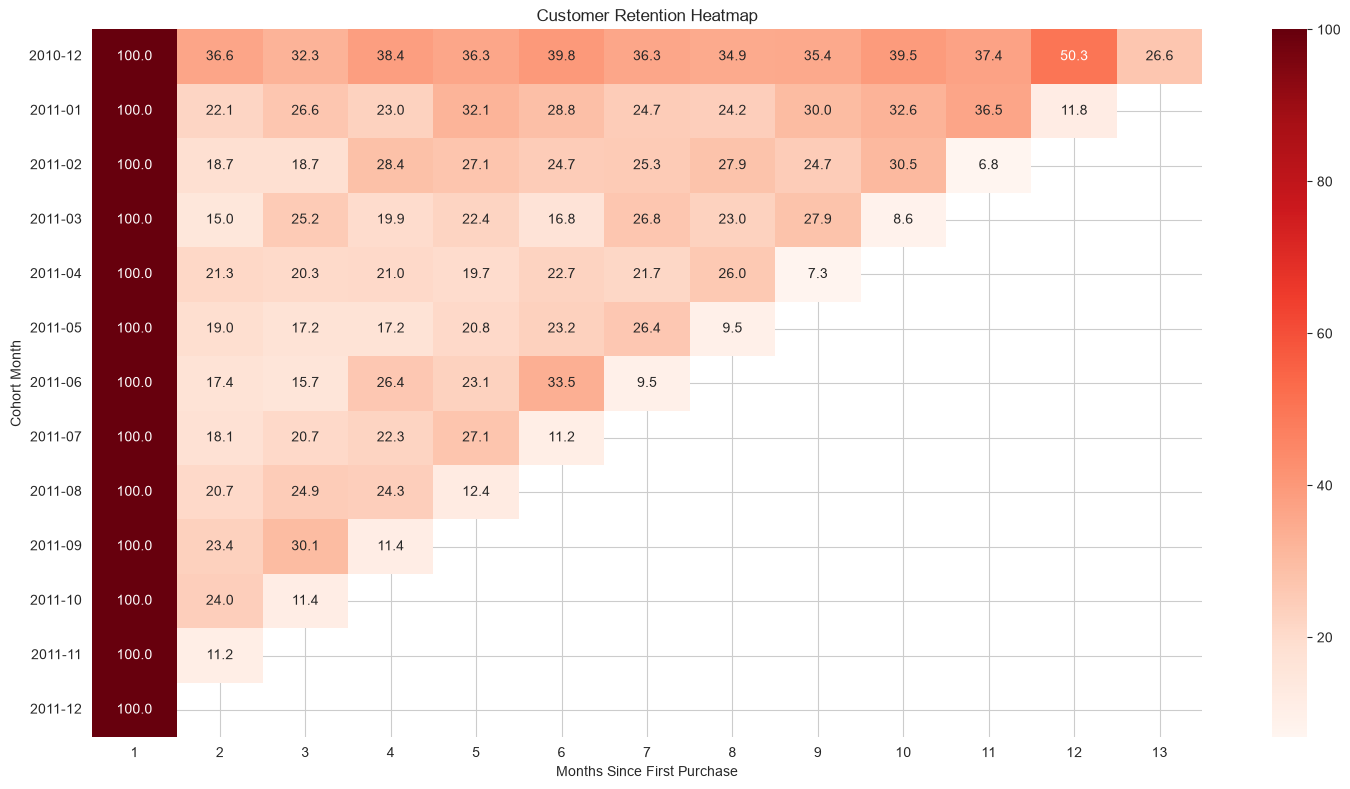

In [44]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    retention,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)

plt.title("Customer Retention Heatmap")

plt.xlabel("Months Since First Purchase")

plt.ylabel("Cohort Month")

plt.tight_layout()

plt.savefig("../outputs/retention_heatmap.png")

plt.show()

In [36]:
cohort_counts.to_csv(
    "../outputs/cohort_matrix.csv"
)

retention.to_csv(
    "../outputs/retention_matrix.csv"
)

In [35]:
retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28,26.55
2011-01,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75,NaN
2011-02,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,6.84,NaN,NaN
2011-03,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,8.63,NaN,NaN,NaN
2011-04,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,7.33,NaN,NaN,NaN,NaN
2011-05,100.0,19.01,17.25,17.25,20.77,23.24,26.41,9.51,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.36,15.70,26.45,23.14,33.47,9.50,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.09,20.74,22.34,27.13,11.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.71,24.85,24.26,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
retention = (
    retention * 100
).round(2)

In [33]:
retention = cohort_counts.divide(
    cohort_size,
    axis=0
)

In [32]:
cohort_size = cohort_counts.iloc[:, 0]

In [31]:
cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

In [29]:
cohort_data.head()

,CohortMonth,CohortIndex,CustomerID
0,2010-12,1,885
1,2010-12,2,324
2,2010-12,3,286
3,2010-12,4,340
4,2010-12,5,321


In [28]:
cohort_data = (
    df.groupby(
        [
            "CohortMonth",
            "CohortIndex"
        ]
    )["CustomerID"]
    .nunique()
    .reset_index()
)

In [27]:
df[
    [
        "CustomerID",
        "InvoiceDate",
        "FirstPurchaseDate",
        "CohortIndex"
    ]
].head()

,CustomerID,InvoiceDate,FirstPurchaseDate,CohortIndex
0,17850,2010-12-01 08:26:00,2010-12-01 08:26:00,1
1,17850,2010-12-01 08:26:00,2010-12-01 08:26:00,1
2,17850,2010-12-01 08:26:00,2010-12-01 08:26:00,1
3,17850,2010-12-01 08:26:00,2010-12-01 08:26:00,1
4,17850,2010-12-01 08:26:00,2010-12-01 08:26:00,1


In [26]:
df["CohortIndex"] = (
    year_diff * 12 +
    month_diff +
    1
)

In [25]:
year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

In [24]:
invoice_month = df["InvoiceDate"].dt.month
cohort_month = df["FirstPurchaseDate"].dt.month

In [23]:
invoice_year = df["InvoiceDate"].dt.year
cohort_year = df["FirstPurchaseDate"].dt.year

In [22]:
df.to_csv(
    "../outputs/cleaned_data.csv",
    index=False
)

In [21]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,FirstPurchaseDate,CohortMonth,TransactionMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01 08:26:00,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01 08:26:00,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01 08:26:00,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01 08:26:00,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01 08:26:00,2010-12,2010-12


In [20]:
df["TransactionMonth"] = (
    df["InvoiceDate"]
      .dt.to_period("M")
)

In [19]:
df["CohortMonth"] = (
    df["FirstPurchaseDate"]
      .dt.to_period("M")
)

In [18]:
df = df.merge(
    first_purchase.rename("FirstPurchaseDate"),
    on="CustomerID"
)

In [17]:
first_purchase = (
    df.groupby("CustomerID")["InvoiceDate"]
      .min()
)

In [16]:
print("Customers :", df["CustomerID"].nunique())

print("Orders :", df["InvoiceNo"].nunique())

print("Revenue :", df["Revenue"].sum())

print("Average Revenue :", df["Revenue"].mean())

Customers : 4338
Orders : 18532
Revenue : 8887208.894000001
Average Revenue : 22.631499735161402


In [15]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [14]:
df = df[df["UnitPrice"] > 0]

In [13]:
df = df[df["Quantity"] > 0]

In [12]:
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [10]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(5225)

In [8]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [7]:
df = df.dropna(subset=["CustomerID"])

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df = pd.read_csv("../data/OnlineRetail.csv", encoding="ISO-8859-1")

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.
